In [1]:
%matplotlib widget
from strategy import CardCounter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

from blackjack_cpp import ProbabilisticRankShoe
import pickle
import os
from pathlib import Path
from blackjack.ev_estimator import EVEstimator
import pickle

In [2]:
df = pd.read_csv("true_edge_vs_count_best.csv") 
print(len(df))

23541


In [3]:
# Analyze card proportions (normalized by total cards)
card_columns = [f"n{r}" for r in range(2, 11)] + ["nA"]
df["total_cards"] = df[card_columns].sum(axis=1)

# Create proportion columns
prop_columns = []
for col in card_columns:
    prop_col = f"{col}_prop"
    df[prop_col] = df[col] / df["total_cards"]
    prop_columns.append(prop_col)

# drop rows with total_cards < 52
df = df[df["total_cards"] >= 52]

In [7]:
# Basic statistics
print("="*60)
print("DATA SUMMARY")
print("\n" * 20)
print("="*60)
print(f"\nEV Statistics (analytical):")
print(f"  Mean:   {df['ev'].mean():.4f}%")
print(f"  Std:    {df['ev'].std():.4f}%")
print(f"  Min:    {df['ev'].min():.2f}%")
print(f"  Max:    {df['ev'].max():.2f}%")
print(f"  Median: {df['ev'].median():.4f}%")

print(f"\nTrue Count Statistics:")
print(f"  Mean:   {df['tc_float'].mean():.3f}")
print(f"  Std:    {df['tc_float'].std():.3f}")
print(f"  Range:  [{df['tc'].min()}, {df['tc'].max()}]")

print(f"\nTotal Cards Statistics:")
print(f"  Mean:   {df['total_cards'].mean():.1f}")
print(f"  Range:  [{df['total_cards'].min()}, {df['total_cards'].max()}]")

print(f"\nData size: {len(df):,} rows")


DATA SUMMARY






















EV Statistics (analytical):
  Mean:   0.0244%
  Std:    1.5988%
  Min:    -6.43%
  Max:    18.19%
  Median: -0.1647%

True Count Statistics:
  Mean:   0.032
  Std:    2.807
  Range:  [-15, 17]

Total Cards Statistics:
  Mean:   181.9
  Range:  [52, 312]

Data size: 20,795 rows


Result type percentages:
  Simple -EV: 11438 (55.00%)
  Simple +EV: 4794 (23.05%)
  Perfect > Count-based: 2413 (11.60%)
  True +EV, Count -EV: 1800 (8.66%)
  True -EV, Count +EV (dangerous): 350 (1.68%)


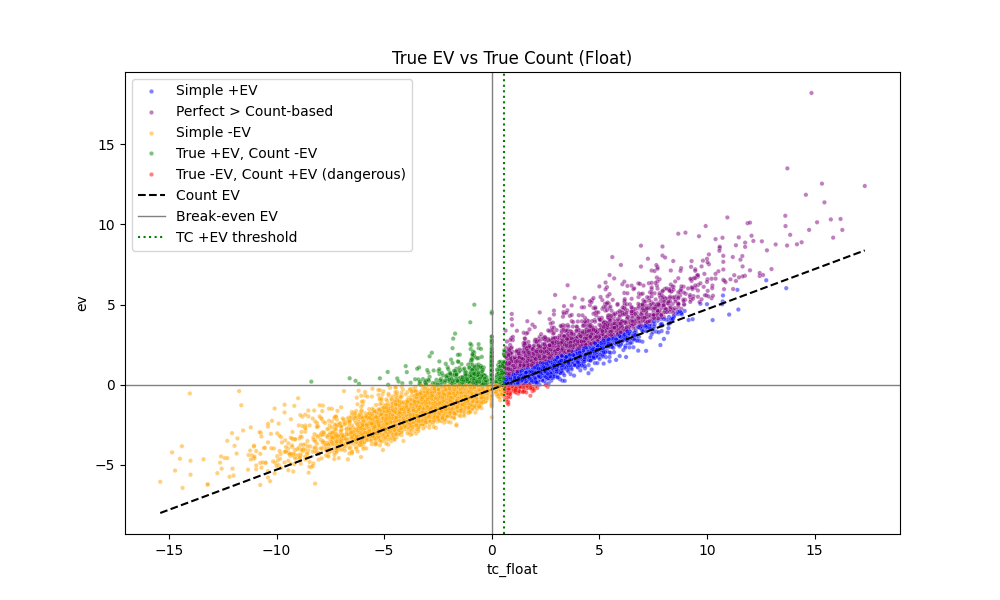

In [4]:
f, ax = plt.subplots(figsize=(10, 6))

ev_tc_0 = -0.292
ev_for_tc = 0.5
ev_line_x = np.array(df["tc_float"])
ev_line_y = ev_tc_0 + ev_for_tc * ev_line_x

true_ev = df["ev"]

# Classify result types
result_type = np.zeros(len(df), dtype=np.int32)
result_type[true_ev < 0] = 0  # simple -ev
result_type[true_ev > 0] = 1  # simple +ev
result_type[(true_ev > 0) & (ev_line_y < (true_ev - 0.5))] = 2  # true perfect strategy better than count-based one
result_type[(ev_line_y < 0) & (true_ev > 0)] = 3  # true perfect strategy is +ev, but count-based is -ev
result_type[(ev_line_y > 0) & (true_ev < 0)] = 4  # true perfect strategy is -ev, but count-based (incorrectly) promises +ev

# Add result_type to dataframe for plotting
df["result_type"] = result_type

# Map result types to labels
result_labels = {
    0: "Simple -EV",
    1: "Simple +EV",
    2: "Perfect > Count-based",
    3: "True +EV, Count -EV",
    4: "True -EV, Count +EV (dangerous)"
}
df["result_label"] = df["result_type"].map(result_labels)

# Print percentages for each class
print("Result type percentages:")
total = len(df)
for type_id, label in result_labels.items():
    count = (df["result_type"] == type_id).sum()
    pct = 100 * count / total
    print(f"  {label}: {count} ({pct:.2f}%)")

# Color palette for result types
palette = {
    "Simple -EV": "orange",
    "Simple +EV": "blue",
    "Perfect > Count-based": "purple",
    "True +EV, Count -EV": "green",
    "True -EV, Count +EV (dangerous)": "red"
}

sns.scatterplot(data=df, x="tc_float", y="ev", hue="result_label", 
                palette=palette, ax=ax, alpha=0.5, s=10)

sns.lineplot(
    x=ev_line_x, y=ev_line_y, color="black", linestyle="--", ax=ax,
    label="Count EV"
)
# horizontal line at y = 0
ax.axhline(0, color="grey", linestyle="-", lw=1, label="Break-even EV")
ax.axvline(0, color="grey", linestyle="-", lw=1)
x_tc_plus_ev = -ev_tc_0 / ev_for_tc
ax.axvline(x_tc_plus_ev, color="green", linestyle=":", label="TC +EV threshold")

ax.set_title("True EV vs True Count (Float)")
ax.legend(loc="upper left")

In [5]:
# Fit regression on proportions
X_prop = df[prop_columns].values
y = df["ev"]

poly_inter = PolynomialFeatures(degree=1, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter_1 = LinearRegression(fit_intercept=True)
reg_inter_1.fit(X_inter, y)
y_pred_inter_1 = reg_inter_1.predict(X_inter)

poly_inter = PolynomialFeatures(degree=2, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter_2 = LinearRegression(fit_intercept=True)
reg_inter_2.fit(X_inter, y)
y_pred_inter_2 = reg_inter_2.predict(X_inter)

poly_inter = PolynomialFeatures(degree=3, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter_3 = LinearRegression(fit_intercept=True)
reg_inter_3.fit(X_inter, y)
y_pred_inter_3 = reg_inter_3.predict(X_inter)

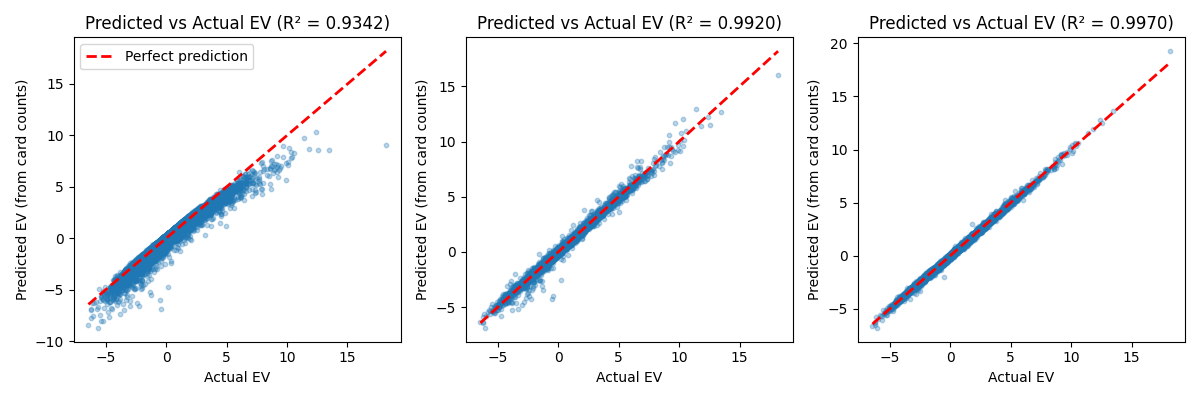

In [6]:
f, axes = plt.subplots(1, 3, figsize=(12, 4))

y_pred_list = [y_pred_inter_1, y_pred_inter_2, y_pred_inter_3]
reg_list = [reg_inter_1, reg_inter_2, reg_inter_3]

for i, (ax, y_pred, reg) in enumerate(zip(axes, y_pred_list, reg_list)):
    degree = i + 1

    ax.scatter(y, y_pred, alpha=0.3, s=10)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel("Actual EV")
    ax.set_ylabel("Predicted EV (from card counts)")
    features = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_prop)
    ax.set_title(f"Predicted vs Actual EV (R² = {reg.score(features, y):.4f})")
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


In [7]:
# 5-fold Cross-Validation: Each point is predicted from a model trained on other points
from sklearn.model_selection import cross_val_predict, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions for each polynomial degree
y_cv_pred_1 = cross_val_predict(
    make_pipeline(PolynomialFeatures(degree=1, include_bias=False), LinearRegression(fit_intercept=True)),
    X_prop, y, cv=kf
)

y_cv_pred_2 = cross_val_predict(
    make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression(fit_intercept=True)),
    X_prop, y, cv=kf
)

y_cv_pred_3 = cross_val_predict(
    make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression(fit_intercept=True)),
    X_prop, y, cv=kf
)


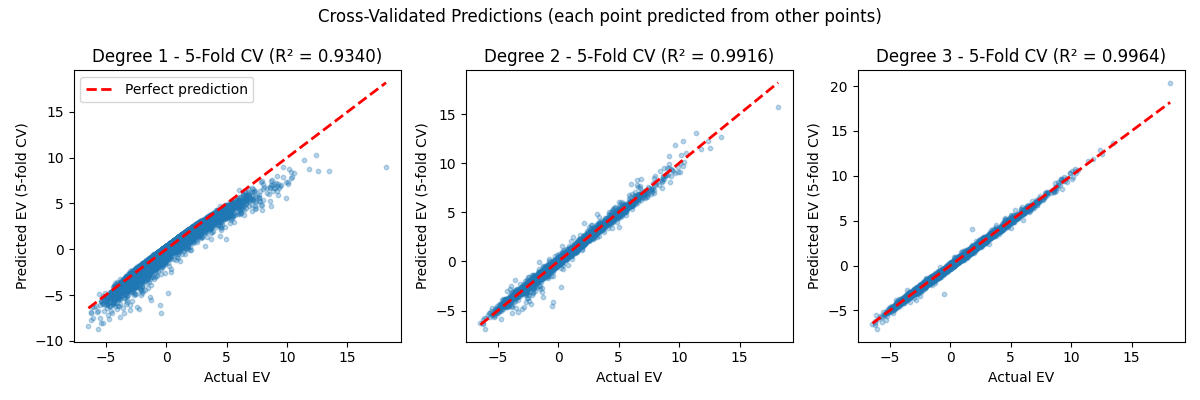

In [8]:
from sklearn.metrics import r2_score

f, axes = plt.subplots(1, 3, figsize=(12, 4))

y_cv_pred_list = [y_cv_pred_1, y_cv_pred_2, y_cv_pred_3]

for i, (ax, y_cv_pred) in enumerate(zip(axes, y_cv_pred_list)):
    degree = i + 1
    r2 = r2_score(y, y_cv_pred)

    ax.scatter(y, y_cv_pred, alpha=0.3, s=10)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel("Actual EV")
    ax.set_ylabel("Predicted EV (5-fold CV)")
    ax.set_title(f"Degree {degree} - 5-Fold CV (R² = {r2:.4f})")
    if i == 0:
        ax.legend()

plt.suptitle("Cross-Validated Predictions (each point predicted from other points)", y=0.98)
plt.tight_layout()
plt.show()


In [9]:
# F-test for nested model comparison
from scipy import stats

n = len(y)

# Get number of parameters for each model
poly_1 = PolynomialFeatures(degree=1, include_bias=False)
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
poly_3 = PolynomialFeatures(degree=3, include_bias=False)

X_1 = poly_1.fit_transform(X_prop)
X_2 = poly_2.fit_transform(X_prop)
X_3 = poly_3.fit_transform(X_prop)

p1 = X_1.shape[1]  # number of parameters in degree 1 model
p2 = X_2.shape[1]  # number of parameters in degree 2 model
p3 = X_3.shape[1]  # number of parameters in degree 3 model

# Calculate RSS (Residual Sum of Squares) for each model
RSS_1 = np.sum((y - y_pred_inter_1) ** 2)
RSS_2 = np.sum((y - y_pred_inter_2) ** 2)
RSS_3 = np.sum((y - y_pred_inter_3) ** 2)

print("Model Statistics:")
print(f"  Degree 1: {p1} parameters, RSS = {RSS_1:.4f}")
print(f"  Degree 2: {p2} parameters, RSS = {RSS_2:.4f}")
print(f"  Degree 3: {p3} parameters, RSS = {RSS_3:.4f}")
print()

# F-test: Degree 1 vs Degree 2
# F = ((RSS_reduced - RSS_full) / (p_full - p_reduced)) / (RSS_full / (n - p_full))
F_1vs2 = ((RSS_1 - RSS_2) / (p2 - p1)) / (RSS_2 / (n - p2))
p_value_1vs2 = 1 - stats.f.cdf(F_1vs2, p2 - p1, n - p2)

print("F-test: Degree 1 vs Degree 2")
print(f"  F-statistic = {F_1vs2:.4f}")
print(f"  df1 = {p2 - p1}, df2 = {n - p2}")
print(f"  p-value = {p_value_1vs2:.2e}")
print(f"  Significant at α=0.05: {p_value_1vs2 < 0.05}")
print()

# F-test: Degree 2 vs Degree 3
F_2vs3 = ((RSS_2 - RSS_3) / (p3 - p2)) / (RSS_3 / (n - p3))
p_value_2vs3 = 1 - stats.f.cdf(F_2vs3, p3 - p2, n - p3)

print("F-test: Degree 2 vs Degree 3")
print(f"  F-statistic = {F_2vs3:.4f}")
print(f"  df1 = {p3 - p2}, df2 = {n - p3}")
print(f"  p-value = {p_value_2vs3:.2e}")
print(f"  Significant at α=0.05: {p_value_2vs3 < 0.05}")
print()

# Overall F-test: Degree 1 vs Degree 3
F_1vs3 = ((RSS_1 - RSS_3) / (p3 - p1)) / (RSS_3 / (n - p3))
p_value_1vs3 = 1 - stats.f.cdf(F_1vs3, p3 - p1, n - p3)

print("F-test: Degree 1 vs Degree 3")
print(f"  F-statistic = {F_1vs3:.4f}")
print(f"  df1 = {p3 - p1}, df2 = {n - p3}")
print(f"  p-value = {p_value_1vs3:.2e}")
print(f"  Significant at α=0.05: {p_value_1vs3 < 0.05}")



Model Statistics:
  Degree 1: 10 parameters, RSS = 3495.8961
  Degree 2: 65 parameters, RSS = 424.6663
  Degree 3: 285 parameters, RSS = 160.4199

F-test: Degree 1 vs Degree 2
  F-statistic = 2725.8448
  df1 = 55, df2 = 20730
  p-value = 1.11e-16
  Significant at α=0.05: True

F-test: Degree 2 vs Degree 3
  F-statistic = 153.5656
  df1 = 220, df2 = 20510
  p-value = 1.11e-16
  Significant at α=0.05: True

F-test: Degree 1 vs Degree 3
  F-statistic = 1550.7174
  df1 = 275, df2 = 20510
  p-value = 1.11e-16
  Significant at α=0.05: True


In [10]:
X_prop_ext = df[prop_columns + ["total_cards"]].values
# F-tests: Does adding extra columns (total_cards) improve the model?
# Compare: proportions only vs proportions + total_cards

print("Feature comparison:")
print(f"  Proportions only: {X_prop.shape[1]} base features")
print(f"  Proportions + total_cards: {X_prop_ext.shape[1]} base features")
print()

# Fit extended models for each degree
poly_ext_1 = PolynomialFeatures(degree=1, include_bias=False)
X_ext_1 = poly_ext_1.fit_transform(X_prop_ext)
reg_ext_1 = LinearRegression(fit_intercept=True).fit(X_ext_1, y)
y_pred_ext_1 = reg_ext_1.predict(X_ext_1)

poly_ext_2 = PolynomialFeatures(degree=2, include_bias=False)
X_ext_2 = poly_ext_2.fit_transform(X_prop_ext)
reg_ext_2 = LinearRegression(fit_intercept=True).fit(X_ext_2, y)
y_pred_ext_2 = reg_ext_2.predict(X_ext_2)

poly_ext_3 = PolynomialFeatures(degree=3, include_bias=False)
X_ext_3 = poly_ext_3.fit_transform(X_prop_ext)
reg_ext_3 = LinearRegression(fit_intercept=True).fit(X_ext_3, y)
y_pred_ext_3 = reg_ext_3.predict(X_ext_3)

# RSS for extended models
RSS_ext_1 = np.sum((y - y_pred_ext_1) ** 2)
RSS_ext_2 = np.sum((y - y_pred_ext_2) ** 2)
RSS_ext_3 = np.sum((y - y_pred_ext_3) ** 2)

p_ext_1 = X_ext_1.shape[1]
p_ext_2 = X_ext_2.shape[1]
p_ext_3 = X_ext_3.shape[1]

print("Extended Model Statistics (proportions + total_cards):")
print(f"  Degree 1: {p_ext_1} parameters, RSS = {RSS_ext_1:.4f}, R² = {reg_ext_1.score(X_ext_1, y):.4f}")
print(f"  Degree 2: {p_ext_2} parameters, RSS = {RSS_ext_2:.4f}, R² = {reg_ext_2.score(X_ext_2, y):.4f}")
print(f"  Degree 3: {p_ext_3} parameters, RSS = {RSS_ext_3:.4f}, R² = {reg_ext_3.score(X_ext_3, y):.4f}")
print()

print("Original Model Statistics (proportions only):")
print(f"  Degree 1: {p1} parameters, RSS = {RSS_1:.4f}")
print(f"  Degree 2: {p2} parameters, RSS = {RSS_2:.4f}")
print(f"  Degree 3: {p3} parameters, RSS = {RSS_3:.4f}")
print()

# F-tests: proportions vs proportions + total_cards (for each degree)
print("="*60)
print("F-tests: Does adding total_cards improve the model?")
print("="*60)

for degree, (p_base, RSS_base, p_ext, RSS_ext) in enumerate([
    (p1, RSS_1, p_ext_1, RSS_ext_1),
    (p2, RSS_2, p_ext_2, RSS_ext_2),
    (p3, RSS_3, p_ext_3, RSS_ext_3)
], start=1):
    # Extended model has more parameters, so it's the "full" model
    F_stat = ((RSS_base - RSS_ext) / (p_ext - p_base)) / (RSS_ext / (n - p_ext))
    p_value = 1 - stats.f.cdf(F_stat, p_ext - p_base, n - p_ext)
    
    print(f"\nDegree {degree}: Proportions only vs Proportions + total_cards")
    print(f"  Base model: {p_base} params, RSS = {RSS_base:.4f}")
    print(f"  Extended model: {p_ext} params, RSS = {RSS_ext:.4f}")
    print(f"  Additional params: {p_ext - p_base}")
    print(f"  F-statistic = {F_stat:.4f}")
    print(f"  p-value = {p_value:.2e}")
    print(f"  Significant at α=0.05: {p_value < 0.05}")


Feature comparison:
  Proportions only: 10 base features
  Proportions + total_cards: 11 base features

Extended Model Statistics (proportions + total_cards):
  Degree 1: 11 parameters, RSS = 1934.2745, R² = 0.9636
  Degree 2: 77 parameters, RSS = 333.9606, R² = 0.9937
  Degree 3: 363 parameters, RSS = 194.9639, R² = 0.9963

Original Model Statistics (proportions only):
  Degree 1: 10 parameters, RSS = 3495.8961
  Degree 2: 65 parameters, RSS = 424.6663
  Degree 3: 285 parameters, RSS = 160.4199

F-tests: Does adding total_cards improve the model?

Degree 1: Proportions only vs Proportions + total_cards
  Base model: 10 params, RSS = 3495.8961
  Extended model: 11 params, RSS = 1934.2745
  Additional params: 1
  F-statistic = 16779.8015
  p-value = 1.11e-16
  Significant at α=0.05: True

Degree 2: Proportions only vs Proportions + total_cards
  Base model: 65 params, RSS = 424.6663
  Extended model: 77 params, RSS = 333.9606
  Additional params: 12
  F-statistic = 468.9278
  p-value = 

In [11]:




X_prop_ext_all = df[prop_columns + card_columns].values
# F-tests: Does adding extra columns (all card counts) improve the model?
# Compare: proportions only vs proportions + all card counts

print("Feature comparison:")
print(f"  Proportions + total_cards only: {X_prop_ext.shape[1]} base features")
print(f"  Proportions + all card counts: {X_prop_ext_all.shape[1]} base features")
print()

# Fit extended models for each degree
poly_ext_all_1 = PolynomialFeatures(degree=1, include_bias=False)
X_ext_all_1 = poly_ext_all_1.fit_transform(X_prop_ext_all)
reg_ext_all_1 = LinearRegression(fit_intercept=True).fit(X_ext_all_1, y)
y_pred_ext_all_1 = reg_ext_all_1.predict(X_ext_all_1)

poly_ext_all_2 = PolynomialFeatures(degree=2, include_bias=False)
X_ext_all_2 = poly_ext_all_2.fit_transform(X_prop_ext_all)
reg_ext_all_2 = LinearRegression(fit_intercept=True).fit(X_ext_all_2, y)
y_pred_ext_all_2 = reg_ext_all_2.predict(X_ext_all_2)

poly_ext_all_3 = PolynomialFeatures(degree=3, include_bias=False)
X_ext_all_3 = poly_ext_all_3.fit_transform(X_prop_ext_all)
reg_ext_all_3 = LinearRegression(fit_intercept=True).fit(X_ext_all_3, y)
y_pred_ext_all_3 = reg_ext_all_3.predict(X_ext_all_3)

# RSS for extended models
RSS_ext_all_1 = np.sum((y - y_pred_ext_all_1) ** 2)
RSS_ext_all_2 = np.sum((y - y_pred_ext_all_2) ** 2)
RSS_ext_all_3 = np.sum((y - y_pred_ext_all_3) ** 2)

p_ext_all_1 = X_ext_all_1.shape[1]
p_ext_all_2 = X_ext_all_2.shape[1]
p_ext_all_3 = X_ext_all_3.shape[1]

print("Extended Model Statistics (proportions + total_cards):")
print(f"  Degree 1: {p_ext_all_1} parameters, RSS = {RSS_ext_all_1:.4f}, R² = {reg_ext_all_1.score(X_ext_all_1, y):.4f}")
print(f"  Degree 2: {p_ext_all_2} parameters, RSS = {RSS_ext_all_2:.4f}, R² = {reg_ext_all_2.score(X_ext_all_2, y):.4f}")
print(f"  Degree 3: {p_ext_all_3} parameters, RSS = {RSS_ext_all_3:.4f}, R² = {reg_ext_all_3.score(X_ext_all_3, y):.4f}")
print()

print("Original Model Statistics (proportions only):")
print(f"  Degree 1: {p_ext_1} parameters, RSS = {RSS_ext_1:.4f}")
print(f"  Degree 2: {p_ext_2} parameters, RSS = {RSS_ext_2:.4f}")
print(f"  Degree 3: {p_ext_3} parameters, RSS = {RSS_ext_3:.4f}")
print()

# F-tests: proportions vs proportions + total_cards (for each degree)
print("="*60)
print("F-tests: Does adding total_cards improve the model?")
print("="*60)

for degree, (p_base, RSS_base, p_ext, RSS_ext) in enumerate([
    (p_ext_1, RSS_ext_1, p_ext_all_1, RSS_ext_all_1),
    (p_ext_2, RSS_ext_2, p_ext_all_2, RSS_ext_all_2),
    (p_ext_3, RSS_ext_3, p_ext_all_3, RSS_ext_all_3)
], start=1):
    # Extended model has more parameters, so it's the "full" model
    F_stat = ((RSS_base - RSS_ext) / (p_ext - p_base)) / (RSS_ext / (n - p_ext))
    p_value = 1 - stats.f.cdf(F_stat, p_ext - p_base, n - p_ext)
    
    print(f"\nDegree {degree}: Proportions only vs Proportions + total_cards")
    print(f"  Base model: {p_base} params, RSS = {RSS_base:.4f}")
    print(f"  Extended model: {p_ext} params, RSS = {RSS_ext:.4f}")
    print(f"  Additional params: {p_ext - p_base}")
    print(f"  F-statistic = {F_stat:.4f}")
    print(f"  p-value = {p_value:.2e}")
    print(f"  Significant at α=0.05: {p_value < 0.05}")

Feature comparison:
  Proportions + total_cards only: 11 base features
  Proportions + all card counts: 20 base features

Extended Model Statistics (proportions + total_cards):
  Degree 1: 20 parameters, RSS = 1898.7977, R² = 0.9643
  Degree 2: 230 parameters, RSS = 290.6561, R² = 0.9945
  Degree 3: 1770 parameters, RSS = 54.2667, R² = 0.9990

Original Model Statistics (proportions only):
  Degree 1: 11 parameters, RSS = 1934.2745
  Degree 2: 77 parameters, RSS = 333.9606
  Degree 3: 363 parameters, RSS = 194.9639

F-tests: Does adding total_cards improve the model?

Degree 1: Proportions only vs Proportions + total_cards
  Base model: 11 params, RSS = 1934.2745
  Extended model: 20 params, RSS = 1898.7977
  Additional params: 9
  F-statistic = 43.1285
  p-value = 1.11e-16
  Significant at α=0.05: True

Degree 2: Proportions only vs Proportions + total_cards
  Base model: 77 params, RSS = 333.9606
  Extended model: 230 params, RSS = 290.6561
  Additional params: 153
  F-statistic = 20.

In [12]:
# Cross-validation comparison: 9 models (3 feature sets × 3 polynomial degrees)
from sklearn.metrics import mean_squared_error

# Define feature sets
X_proportions = df[prop_columns].values                              # 10 features
X_prop_total = np.column_stack([X_prop, df["total_cards"].values])   # 11 features  
X_counts = df[prop_columns + card_columns].values                    # 20 features (proportions + raw counts)

feature_sets = {
    "Proportions": X_proportions,
    "Prop + total_cards": X_prop_total,
    "Prop + raw counts": X_counts
}

degrees = [1, 2, 3]
degree_names = {1: "Linear", 2: "Quadratic", 3: "Cubic"}

# Compute CV scores for all 9 models
results = []
for feat_name, X_feat in feature_sets.items():
    for degree in degrees:
        pipeline = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LinearRegression(fit_intercept=True)
        )
        
        # Cross-validated predictions
        y_cv_pred = cross_val_predict(pipeline, X_feat, y, cv=kf)
        r2_cv = r2_score(y, y_cv_pred)
        rmse_cv = np.sqrt(mean_squared_error(y, y_cv_pred))
        
        # Training metrics
        pipeline.fit(X_feat, y)
        y_train_pred = pipeline.predict(X_feat)
        r2_train = pipeline.score(X_feat, y)
        rmse_train = np.sqrt(mean_squared_error(y, y_train_pred))
        
        # Number of polynomial features
        n_features = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_feat[:1]).shape[1]
        
        results.append({
            "Features": feat_name,
            "Degree": degree_names[degree],
            "Base Features": X_feat.shape[1],
            "Poly Features": n_features,
            "R² (train)": r2_train,
            "R² (CV)": r2_cv,
            "RMSE (train)": rmse_train,
            "RMSE (CV)": rmse_cv,
            "Overfit": r2_train - r2_cv
        })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Print nicely formatted table
print("="*110)
print("Cross-Validation Comparison: 9 Models")
print("="*110)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()

# Pivot table for easier comparison
print("\nR² (CV) by Feature Set and Degree:")
print("-"*50)
pivot = results_df.pivot(index="Features", columns="Degree", values="R² (CV)")
pivot = pivot[["Linear", "Quadratic", "Cubic"]]  # reorder columns
print(pivot.to_string(float_format=lambda x: f"{x:.4f}"))
print()

print("\nRMSE (CV) by Feature Set and Degree:")
print("-"*50)
pivot_rmse = results_df.pivot(index="Features", columns="Degree", values="RMSE (CV)")
pivot_rmse = pivot_rmse[["Linear", "Quadratic", "Cubic"]]
print(pivot_rmse.to_string(float_format=lambda x: f"{x:.4f}"))
print()

print("\nOverfit (Train - CV) by Feature Set and Degree:")
print("-"*50)
pivot_overfit = results_df.pivot(index="Features", columns="Degree", values="Overfit")
pivot_overfit = pivot_overfit[["Linear", "Quadratic", "Cubic"]]
print(pivot_overfit.to_string(float_format=lambda x: f"{x:.4f}"))


Cross-Validation Comparison: 9 Models
          Features    Degree  Base Features  Poly Features  R² (train)  R² (CV)  RMSE (train)  RMSE (CV)  Overfit
       Proportions    Linear             10             10      0.9342   0.9340        0.4100     0.4108   0.0002
       Proportions Quadratic             10             65      0.9920   0.9916        0.1429     0.1461   0.0004
       Proportions     Cubic             10            285      0.9970   0.9964        0.0878     0.0965   0.0006
Prop + total_cards    Linear             11             11      0.9636   0.9635        0.3050     0.3055   0.0001
Prop + total_cards Quadratic             11             77      0.9937   0.9934        0.1267     0.1301   0.0003
Prop + total_cards     Cubic             11            363      0.9963   0.9968        0.0968     0.0905  -0.0005
 Prop + raw counts    Linear             20             20      0.9643   0.9641        0.3022     0.3031   0.0002
 Prop + raw counts Quadratic             20       

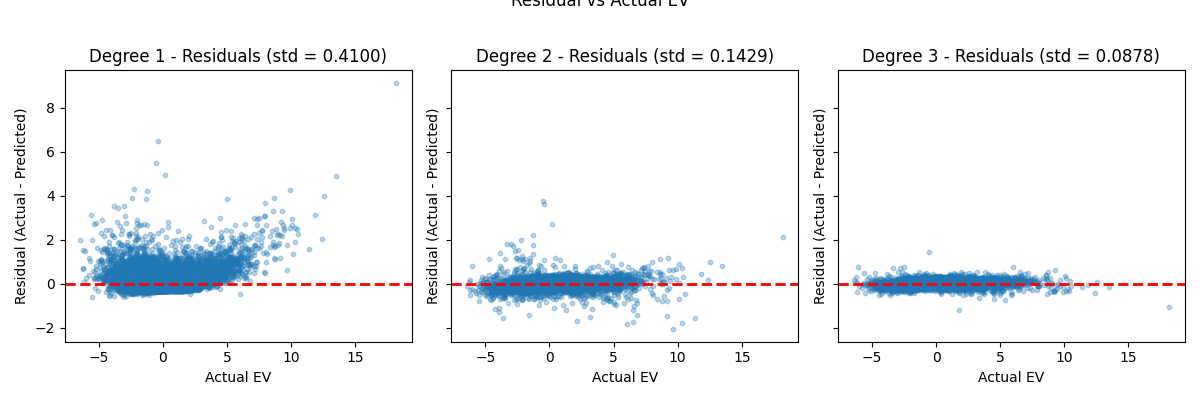

In [13]:
# Residual plots: residual (actual - predicted) vs actual EV
f, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

residuals = [
    y - y_pred_inter_1,
    y - y_pred_inter_2,
    y - y_pred_inter_3
]

for i, (ax, res) in enumerate(zip(axes, residuals)):
    degree = i + 1
    
    ax.scatter(y, res, alpha=0.3, s=10)
    ax.axhline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel("Actual EV")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"Degree {degree} - Residuals (std = {np.std(res):.4f})")

plt.suptitle("Residual vs Actual EV", y=1.02)
plt.tight_layout()
plt.show()


## EV vs Count

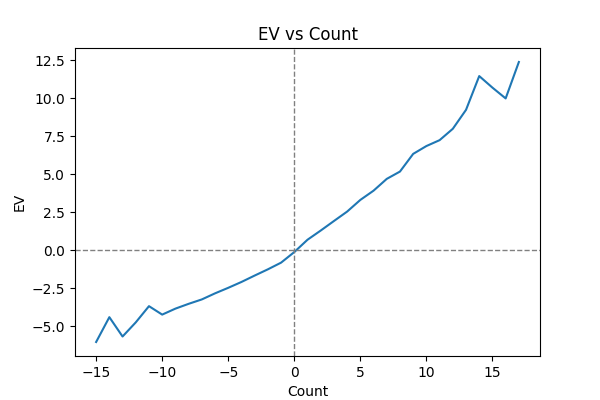

In [14]:
f, ax0 = plt.subplots(1, 1, figsize=(6, 4))


df.groupby("tc")["ev"].mean().plot(kind="line", ax=ax0)
ax0.set_title("EV vs Count")
ax0.set_xlabel("Count")
ax0.set_ylabel("EV")
ax0.axhline(0, color="grey", linestyle="--", lw=1)
ax0.axvline(0, color="grey", linestyle="--", lw=1)

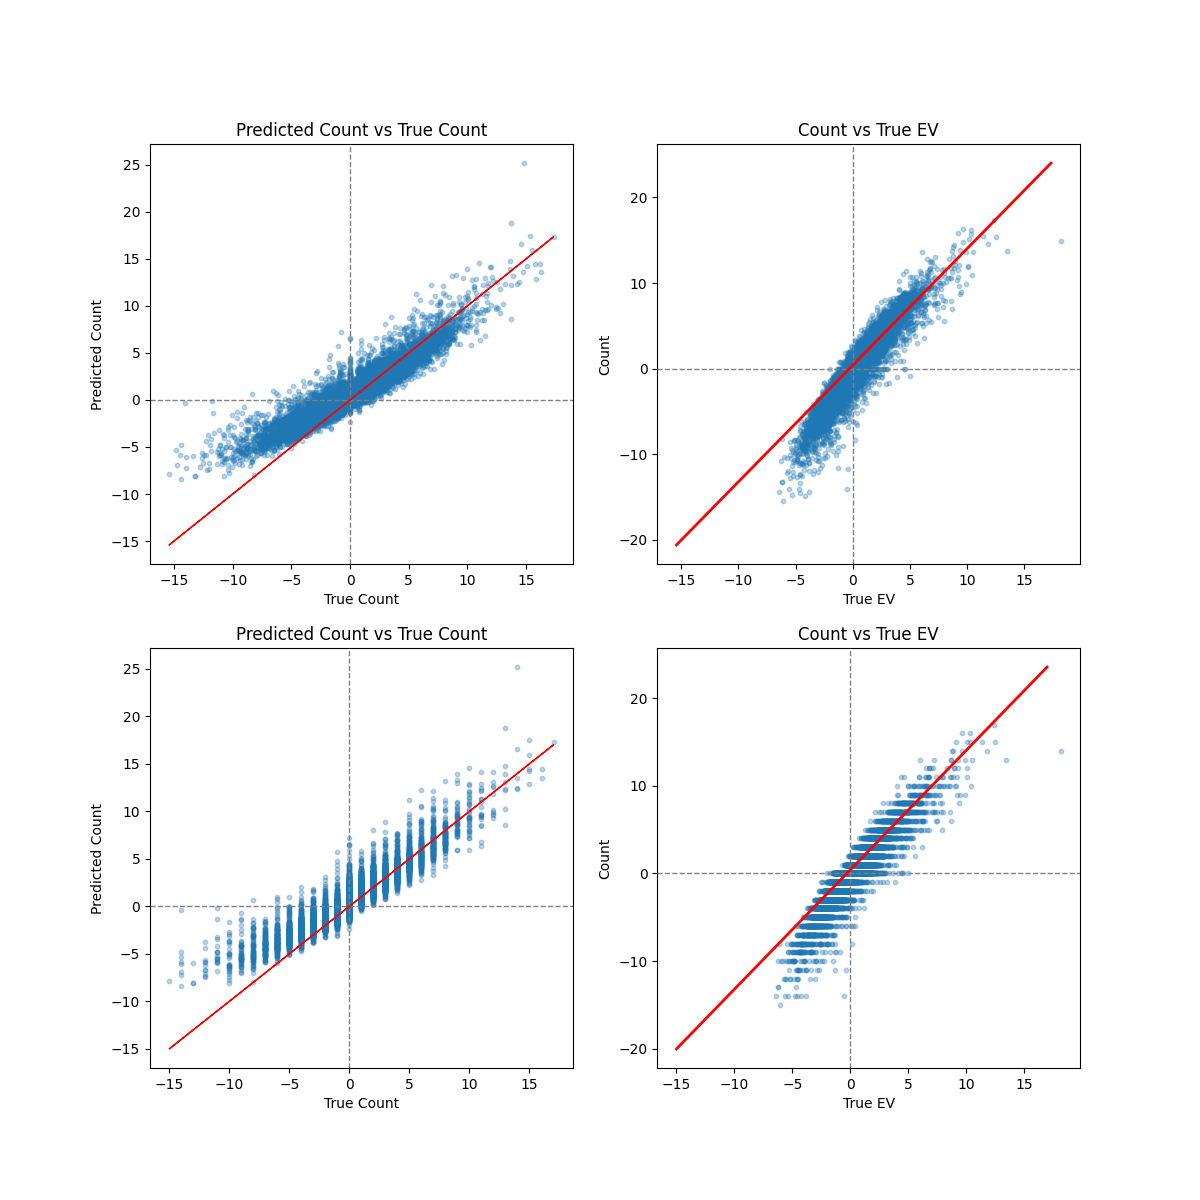

In [15]:
# model true count as a function of ev
# this will be used to determine bet sizes in ev model to match count-based model
# fit a linear regression model to the data
count_estimate_model = LinearRegression()
features = PolynomialFeatures(degree=1, include_bias=False)

# only model on counts from 0
data = df[df["tc_float"] > -1]
count_estimate_model.fit(features.fit_transform(data[["ev"]]), data["tc_float"])
tc_pred = count_estimate_model.predict(features.fit_transform(df[["ev"]]))

# plot tc_pred vs tc
f, axes = plt.subplots(2, 2, figsize=(12, 12))

target_keys = ["tc_float", "tc"]
for key, ax_row in zip(target_keys, axes):
    ax1, ax2 = ax_row
    ax1.scatter(df[key], tc_pred, alpha=0.3, s=10)
    ax1.set_xlabel("True Count")
    ax1.set_ylabel("Predicted Count")
    ax1.axhline(0, color="grey", linestyle="--", lw=1)
    ax1.axvline(0, color="grey", linestyle="--", lw=1)
    ax1.set_title("Predicted Count vs True Count")
    # plot 1-to-1 line
    ax1.plot(df[key], df[key], color="red", linestyle="-", lw=1)

    # plot best-fit line
    tc_pred_line = np.array([df[key].min(), df[key].max()])
    ev_pred_line = count_estimate_model.predict(features.fit_transform(tc_pred_line[:, np.newaxis]))
    ax2.scatter(df["ev"], df[key], alpha=0.3, s=10)
    ax2.set_xlabel("True EV")
    ax2.set_ylabel("Count")
    ax2.set_title("Count vs True EV")
    ax2.axhline(0, color="grey", linestyle="--", lw=1)
    ax2.axvline(0, color="grey", linestyle="--", lw=1)
    ax2.plot(tc_pred_line, ev_pred_line, color="red", lw=2, ls="-")





In [16]:
count_estimate_model.coef_

array([1.3620036])

In [17]:
count_estimate_model.predict([[-0.262]])

array([0.04491963])

In [ ]:
models_dir = Path("../sklearn_models")


# 1. Train and save cubic EV estimator with individual counts (not total)
X_raw = df[card_columns].values
y_values = df["ev"].values

ev_model_cubic = EVEstimator(degree=3, keep_total_count=False, keep_individual_counts=True)
ev_model_cubic.fit(X_raw, y_values)

# Cross-validated R² for reference
y_cv_cubic = cross_val_predict(ev_model_cubic, X_raw, y_values, cv=5)
ev_model_cubic.r2_cv = r2_score(y_values, y_cv_cubic)

print(f"Cubic EV Estimator (with individual counts):")
print(f"  {ev_model_cubic}")
print(f"  Cross-validated R²: {ev_model_cubic.r2_cv:.4f}")

ev_model_path = models_dir / "ev_estimator_cubic.pkl"
with open(ev_model_path, "wb") as f:
    pickle.dump(ev_model_cubic, f)
print(f"  Saved to: {ev_model_path}")

# 2. Save synthetic count model (predicts count from EV)
# This model is already trained as count_estimate_model
synthetic_count_path = models_dir / "synthetic_count_from_ev.pkl"
with open(synthetic_count_path, "wb") as f:
    pickle.dump(count_estimate_model, f)
print(f"\nSynthetic count model (EV → count):")
print(f"  Saved to: {synthetic_count_path}")


Cubic EV Estimator (with individual counts):
  EVEstimator(degree=3, fitted, R²=0.9990)
  Cross-validated R²: 0.9984
  Saved to: ../sklearn_models/ev_estimator_cubic.pkl

Synthetic count model (EV → count):
  Coefficient: 1.3620
  Saved to: ../sklearn_models/synthetic_count_from_ev.pkl


In [20]:
# Full pipeline: EV model (CV) → synthetic count model → predicted count
# This shows how well we can predict count using the EV-based approach

# Step 1: Get CV predictions from the full cubic EV model
ev_model_full = EVEstimator(degree=3, keep_total_count=False, keep_individual_counts=True)
ev_cv_pred = cross_val_predict(ev_model_full, X_raw, y_values, cv=kf)

# Step 2: Use synthetic count model to predict count from CV-predicted EV
# count_estimate_model expects features from PolynomialFeatures(degree=1)
count_features = PolynomialFeatures(degree=1, include_bias=False)
synthetic_count_pred = count_estimate_model.predict(count_features.fit_transform(ev_cv_pred.reshape(-1, 1)))

# True count
true_count = df["tc_float"].values

# Residuals
count_residuals = synthetic_count_pred - true_count

print(f"Synthetic Count Prediction (via CV EV model):")
print(f"  EV model CV R²: {r2_score(y_values, ev_cv_pred):.4f}")
print(f"  Count prediction R²: {r2_score(true_count, synthetic_count_pred):.4f}")
print(f"  Count RMSE: {np.sqrt(np.mean(count_residuals**2)):.4f}")
print(f"  Count MAE: {np.mean(np.abs(count_residuals)):.4f}")


Synthetic Count Prediction (via CV EV model):
  EV model CV R²: 0.9984
  Count prediction R²: 0.8153
  Count RMSE: 1.2064
  Count MAE: 0.7801


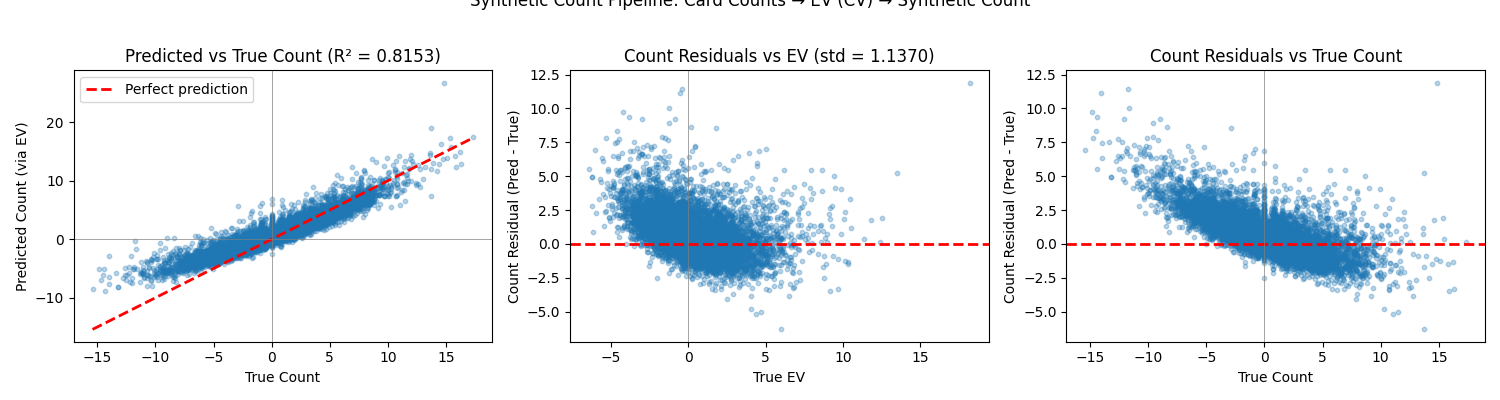

In [21]:
# Plot: Predicted count vs true count, residuals vs EV, residuals vs count
f, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Predicted count vs true count
ax1 = axes[0]
ax1.scatter(true_count, synthetic_count_pred, alpha=0.3, s=10)
ax1.plot([true_count.min(), true_count.max()], [true_count.min(), true_count.max()], 
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel("True Count")
ax1.set_ylabel("Predicted Count (via EV)")
ax1.set_title(f"Predicted vs True Count (R² = {r2_score(true_count, synthetic_count_pred):.4f})")
ax1.axhline(0, color="grey", linestyle="-", lw=0.5)
ax1.axvline(0, color="grey", linestyle="-", lw=0.5)
ax1.legend()

# Plot 2: Residuals vs EV
ax2 = axes[1]
ax2.scatter(y_values, count_residuals, alpha=0.3, s=10)
ax2.axhline(0, color='r', linestyle='--', lw=2)
ax2.set_xlabel("True EV")
ax2.set_ylabel("Count Residual (Pred - True)")
ax2.set_title(f"Count Residuals vs EV (std = {np.std(count_residuals):.4f})")
ax2.axvline(0, color="grey", linestyle="-", lw=0.5)

# Plot 3: Residuals vs true count
ax3 = axes[2]
ax3.scatter(true_count, count_residuals, alpha=0.3, s=10)
ax3.axhline(0, color='r', linestyle='--', lw=2)
ax3.set_xlabel("True Count")
ax3.set_ylabel("Count Residual (Pred - True)")
ax3.set_title(f"Count Residuals vs True Count")
ax3.axvline(0, color="grey", linestyle="-", lw=0.5)

plt.suptitle("Synthetic Count Pipeline: Card Counts → EV (CV) → Synthetic Count", y=1.02)
plt.tight_layout()
plt.show()
